In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# 1. Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ML LAB EXPERIMENTS/customer_churn_dataset.csv')

In [ ]:
# 2. Data Preprocessing
# Drop non-predictive columns (CustomerID)
df_model = df.drop('CustomerID', axis=1)

# Encode categorical variables into numeric values
le = LabelEncoder()
categorical_cols = ['Gender', 'SubscriptionType', 'PaymentMethod', 'ContractType']
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [ ]:
# 3. Feature and Target separation
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [ ]:
# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5. Feature Scaling (essential for models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 6. Model Training - Logistic Regression with Balanced Weights
# 'class_weight=balanced' is used to account for the smaller number of churners.
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
# 7. Model Predictions
y_pred = model.predict(X_test_scaled)

In [ ]:
# 8. Evaluation Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.55

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.52      0.65        33
           1       0.24      0.71      0.36         7

    accuracy                           0.55        40
   macro avg       0.57      0.61      0.51        40
weighted avg       0.78      0.55      0.60        40



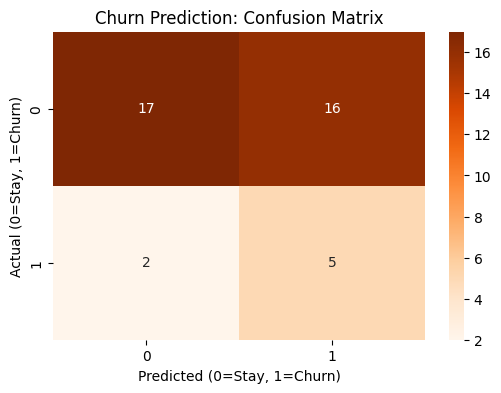

In [ ]:
# 9. Visualization - Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Churn Prediction: Confusion Matrix')
plt.xlabel('Predicted (0=Stay, 1=Churn)')
plt.ylabel('Actual (0=Stay, 1=Churn)')
plt.show()

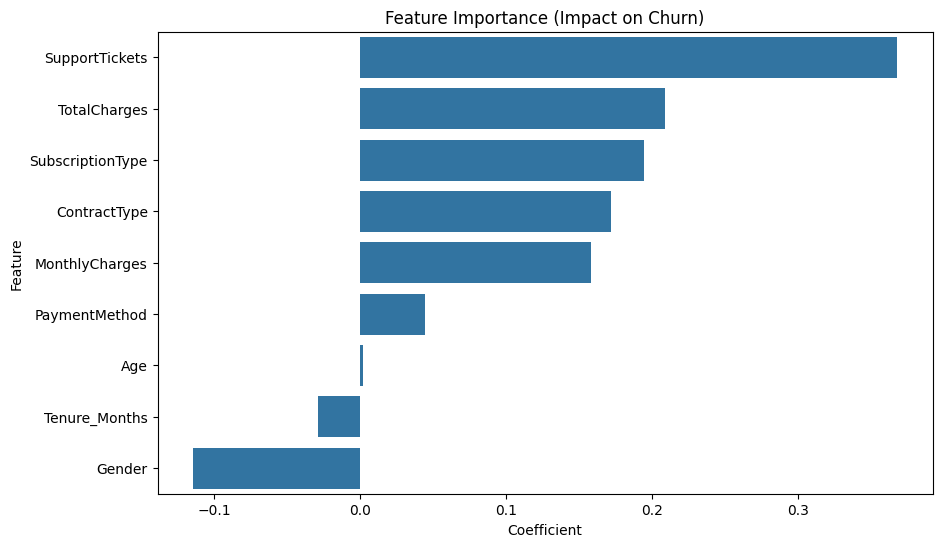

In [ ]:
# 10. Visualization - Feature Importance (Coefficients)
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance (Impact on Churn)')
plt.show()